In [6]:
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sys
sys.path.insert(0, str(Path(".").resolve()))
from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': 16,
    "lines.linewidth": 2,
    "axes.labelsize": 18,
    "axes.titlesize": 22,
})

In [7]:
K_RATIO = 0.01

DATASETS = {
    "Random init": "../bayesian_optimization/runs/mcl1_mmgbsa_seeds_*.sqlite",
    "Stochastic closest (K=50)": "../bayesian_optimization/runs/mcl1_mmgbsa_stochastic_closest_*.sqlite",
}

frames = []
for init_label, pattern in DATASETS.items():
    db_paths = sorted(glob(pattern))
    print(f"{init_label}: found {len(db_paths)} databases")
    for seed_idx, path in enumerate(db_paths):
        data, top_k, source = load_data(path, k_ratio=K_RATIO)
        data["Init Sampler"] = init_label
        data["seed"] = seed_idx
        frames.append(data)

df = pd.concat(frames, ignore_index=True)
size_topk = len(top_k)
print(f"\nTop-{K_RATIO*100:.0f}% threshold: {size_topk} molecules")
print(f"Total rows: {len(df)}, unique seeds per init: {df.groupby('Init Sampler')['seed'].nunique().to_dict()}")

Random init: found 10 databases
Stochastic closest (K=50): found 10 databases

Top-1% threshold: 593 molecules
Total rows: 208858, unique seeds per init: {'Random init': 10, 'Stochastic closest (K=50)': 10}


In [8]:
df["retrieval"] = df["is_top_k_cum"] / size_topk

group_cols = ["Init Sampler", "Embedding Model", "Surrogate", "Iteration"]

agg = (
    df.groupby(group_cols)["retrieval"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)
agg["ci95"] = 1.96 * agg["std"] / np.sqrt(agg["count"])
agg

,Init Sampler,Embedding Model,Surrogate,Iteration,mean,std,min,max,count,ci95
0,Random init,ChemBERTa-2,Linear,0,0.000000,0.000000,0.000000,0.000000,10,0.000000
1,Random init,ChemBERTa-2,Linear,1,0.000000,0.000000,0.000000,0.000000,10,0.000000
2,Random init,ChemBERTa-2,Linear,2,0.000169,0.000533,0.000000,0.001686,10,0.000331
3,Random init,ChemBERTa-2,Linear,3,0.000169,0.000533,0.000000,0.001686,10,0.000331
4,Random init,ChemBERTa-2,Linear,4,0.000337,0.000711,0.000000,0.001686,10,0.000441
...,...,...,...,...,...,...,...,...,...,...
21601,Stochastic closest (K=50),Morgan Fingerprint,Linear,3596,0.475211,0.127747,0.259696,0.629005,10,0.079178
21602,Stochastic closest (K=50),Morgan Fingerprint,Linear,3597,0.475548,0.127504,0.259696,0.629005,10,0.079028
21603,Stochastic closest (K=50),Morgan Fingerprint,Linear,3598,0.475717,0.127414,0.259696,0.629005,10,0.078972
21604,Stochastic closest (K=50),Morgan Fingerprint,Linear,3599,0.475885,0.127097,0.261383,0.629005,10,0.078775


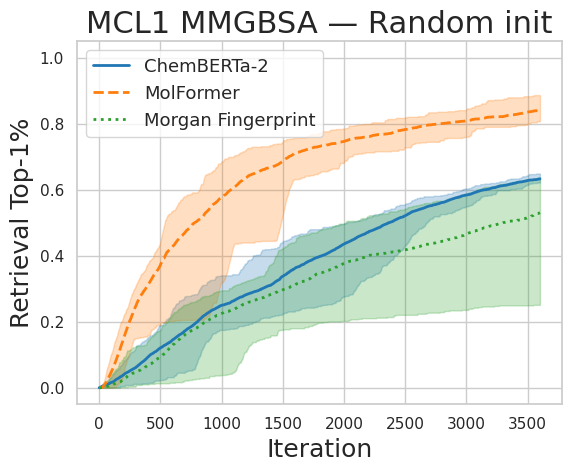

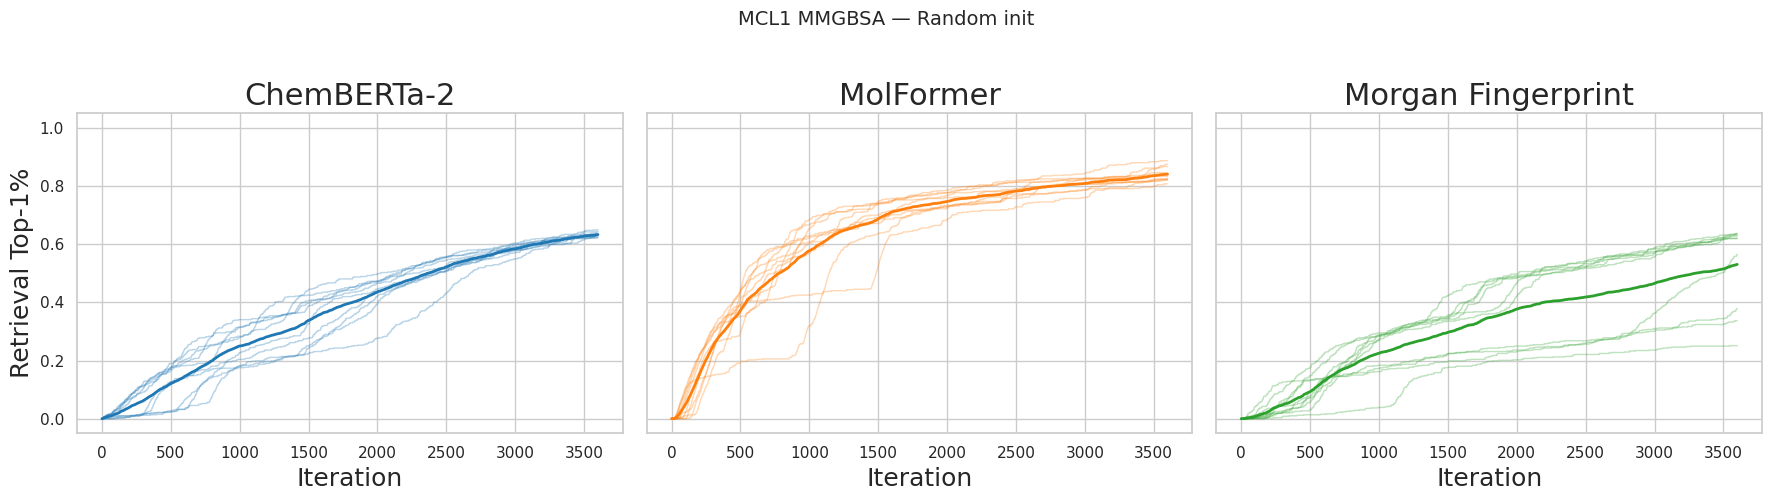

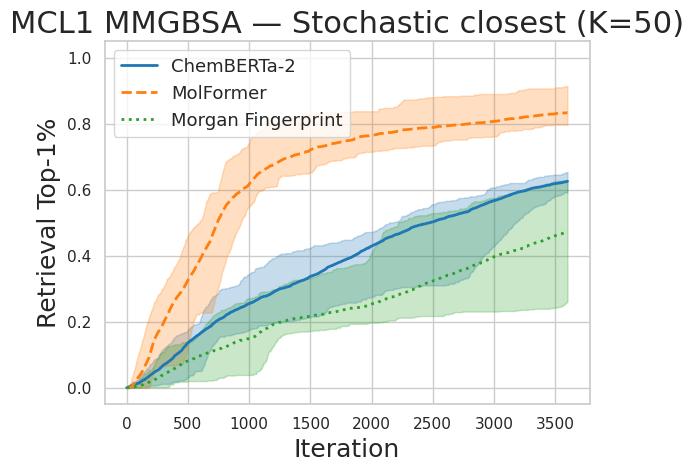

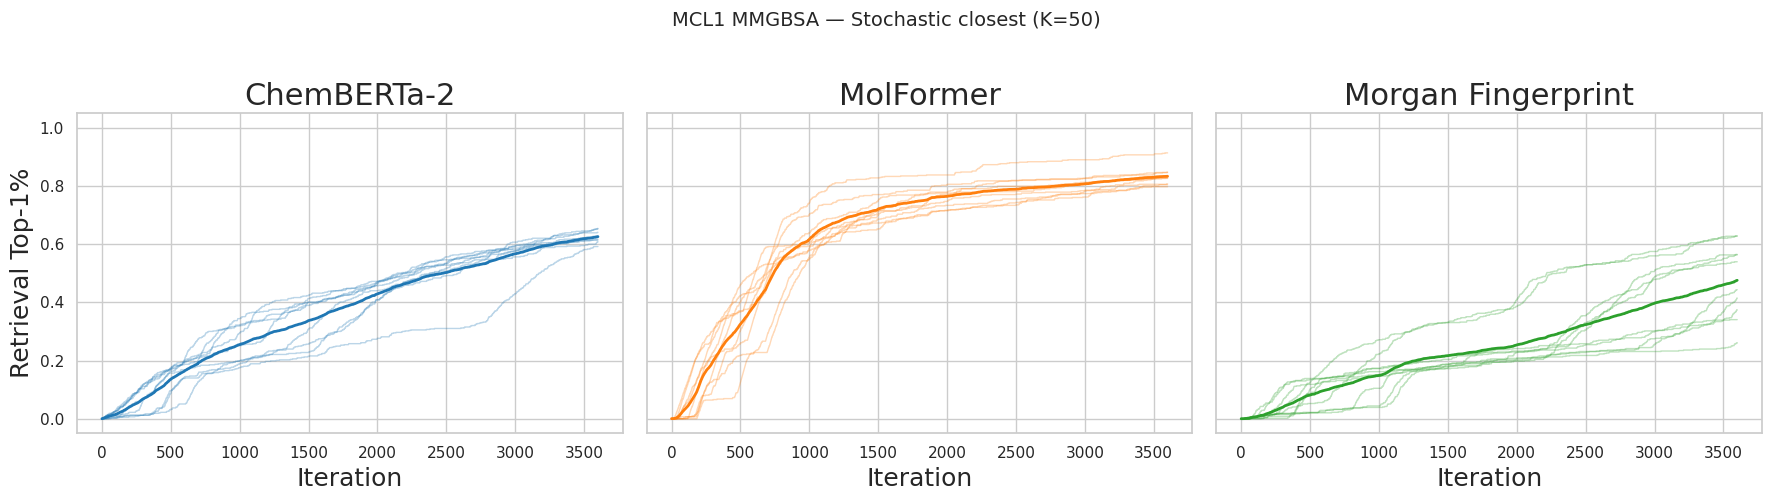

In [9]:
EMBEDDING_STYLES = {
    "ChemBERTa-2": "-",
    "MolFormer": "--",
    "Morgan Fingerprint": ":",
}
SURROGATE_STYLES = {
    "Linear": "-",
    "Random Forest": "--",
}
PALETTE = sns.color_palette("tab10", n_colors=3)
COLORS_EMBEDDING = dict(zip(["ChemBERTa-2", "MolFormer", "Morgan Fingerprint"], PALETTE))

surrogates = agg["Surrogate"].dropna().unique()
surrogate_order = [s for s in ["Linear", "Random Forest"] if s in surrogates]
surrogate_order += [s for s in surrogates if s not in surrogate_order]

embeddings = agg["Embedding Model"].dropna().unique()
embedding_order = [e for e in ["ChemBERTa-2", "MolFormer", "Morgan Fingerprint"] if e in embeddings]
embedding_order += [e for e in embeddings if e not in embedding_order]

INIT_LABELS = ["Random init", "Stochastic closest (K=50)"]

for init_label in INIT_LABELS:
    subset_agg = agg[agg["Init Sampler"] == init_label]
    subset_df = df[df["Init Sampler"] == init_label].copy()
    subset_df["retrieval"] = subset_df["is_top_k_cum"] / size_topk
    safe_label = init_label.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")

    # ── Figure 1: columns per surrogate, lines per embedding, min/max band ──
    fig1, axes1 = plt.subplots(1, len(surrogate_order), figsize=(6 * len(surrogate_order), 5), sharey=True)
    if len(surrogate_order) == 1:
        axes1 = [axes1]

    for ax, surrogate in zip(axes1, surrogate_order):
        for model, group in subset_agg[subset_agg["Surrogate"] == surrogate].groupby("Embedding Model"):
            group = group.sort_values("Iteration")
            color = COLORS_EMBEDDING[model]
            ax.fill_between(group["Iteration"], group["min"], group["max"], color=color, alpha=0.25)
            ax.plot(group["Iteration"], group["mean"],
                    color=color, linestyle=EMBEDDING_STYLES[model], label=model)
        ax.set_title(f"MCL1 MMGBSA — {init_label}")
        ax.set_xlabel("Iteration")
        ax.set_ylim(-0.05, 1.05)

    axes1[0].set_ylabel(f"Retrieval Top-{K_RATIO*100:.0f}%")
    handles, labels = axes1[0].get_legend_handles_labels()
    axes1[-1].legend(handles, labels, loc="upper left", frameon=True, fontsize=13)
    fig1.tight_layout()
    fig1.savefig(f"figures/seeds_ci_{safe_label}.svg", bbox_inches="tight")
    fig1.savefig(f"figures/seeds_ci_{safe_label}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    # ── Figure 2: columns per embedding, all seed trajectories + mean ───────
    fig2, axes2 = plt.subplots(1, len(embedding_order), figsize=(6 * len(embedding_order), 5), sharey=True)
    if len(embedding_order) == 1:
        axes2 = [axes2]

    for ax, embedding in zip(axes2, embedding_order):
        color = COLORS_EMBEDDING[embedding]
        emb_df = subset_df[subset_df["Embedding Model"] == embedding]
        emb_agg = subset_agg[subset_agg["Embedding Model"] == embedding]
        for surrogate, surr_df in emb_df.groupby("Surrogate"):
            ls = SURROGATE_STYLES.get(surrogate, "-")
            for _, seed_df in surr_df.groupby("seed"):
                seed_df = seed_df.sort_values("Iteration")
                ax.plot(seed_df["Iteration"], seed_df["retrieval"],
                        color=color, linestyle=ls, linewidth=1, alpha=0.3)
            # mean on top
            mean_group = emb_agg[emb_agg["Surrogate"] == surrogate].sort_values("Iteration")
            ax.plot(mean_group["Iteration"], mean_group["mean"],
                    color=color, linestyle=ls, linewidth=2)
        ax.set_title(embedding)
        ax.set_xlabel("Iteration")
        ax.set_ylim(-0.05, 1.05)

    axes2[0].set_ylabel(f"Retrieval Top-{K_RATIO*100:.0f}%")
    fig2.suptitle(f"MCL1 MMGBSA — {init_label}", fontsize=14, y=1.01)
    fig2.tight_layout()
    fig2.savefig(f"figures/seeds_spread_{safe_label}.svg", bbox_inches="tight")
    plt.savefig(f"figures/seeds_spread_{safe_label}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [10]:
final = (
    agg.loc[agg.groupby(["Init Sampler", "Embedding Model", "Surrogate"])["Iteration"].idxmax()]
    .drop(columns=["Iteration", "std", "count"])
    .rename(columns={"mean": "Retrieval (mean)", "ci95": "± 95% CI"})
    .sort_values(["Surrogate", "Embedding Model", "Init Sampler"])
    .reset_index(drop=True)
)
final["Retrieval (mean)"] = final["Retrieval (mean)"].map("{:.3f}".format)
final["± 95% CI"] = final["± 95% CI"].map("{:.3f}".format)
final.sort_values(by=["Init Sampler", "Embedding Model"])

,Init Sampler,Embedding Model,Surrogate,Retrieval (mean),min,max,± 95% CI
0,Random init,ChemBERTa-2,Linear,0.633,0.622260,0.649241,0.006
2,Random init,MolFormer,Linear,0.841,0.807757,0.887015,0.017
4,Random init,Morgan Fingerprint,Linear,0.531,0.251265,0.637437,0.092
1,Stochastic closest (K=50),ChemBERTa-2,Linear,0.626,0.591906,0.654300,0.014
3,Stochastic closest (K=50),MolFormer,Linear,0.834,0.797639,0.913997,0.023
5,Stochastic closest (K=50),Morgan Fingerprint,Linear,0.476,0.261383,0.629005,0.079
